# 📊 Text Classification Project

This notebook includes:
- Exploratory Data Analysis (EDA)
- Text preprocessing for NLP

## 1. Load Data

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

data = []

with open('/content/News_Category_Dataset_v3.json', 'r') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


## 2. Data Overview

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   link               209527 non-null  object
 1   headline           209527 non-null  object
 2   category           209527 non-null  object
 3   short_description  209527 non-null  object
 4   authors            209527 non-null  object
 5   date               209527 non-null  object
dtypes: object(6)
memory usage: 9.6+ MB


In [3]:
df.isnull().sum()

,0
link,0
headline,0
category,0
short_description,0
authors,0
date,0


## 3. Category Distribution

In [4]:
category_counts = df['category'].value_counts()

category_counts.head(10)

,count
category,
POLITICS,35602
WELLNESS,17945
ENTERTAINMENT,17362
TRAVEL,9900
STYLE & BEAUTY,9814
PARENTING,8791
HEALTHY LIVING,6694
QUEER VOICES,6347
FOOD & DRINK,6340


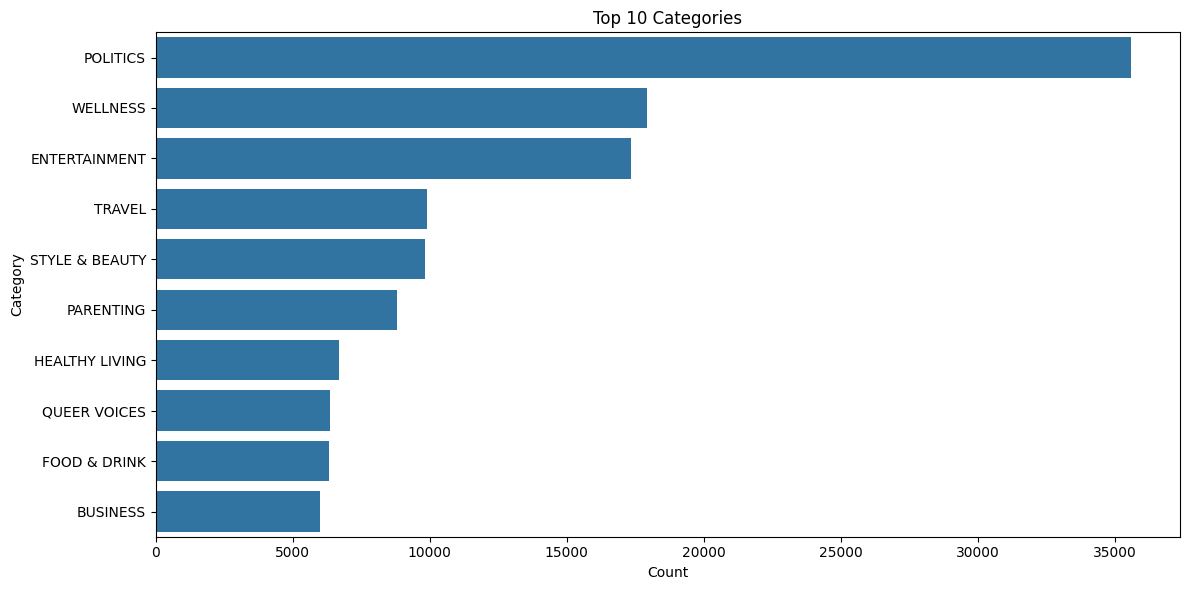

In [5]:
top_categories = category_counts.head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_categories.values, y=top_categories.index)

plt.title("Top 10 Categories")
plt.xlabel("Count")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## 4. Text Length Analysis

In [6]:
df['text'] = df['headline'] + " " + df['short_description']
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

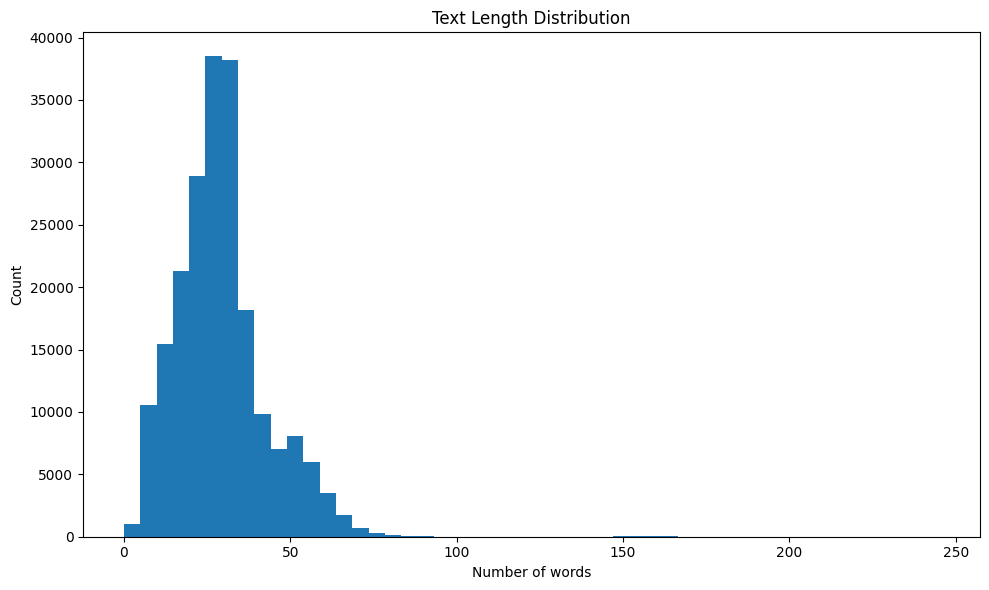

In [7]:
plt.figure(figsize=(10,6))
plt.hist(df['text_length'], bins=50)

plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 5. Text Cleaning

In [8]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

df[['text','clean_text']].head()

,text,clean_text
0,Over 4 Million Americans Roll Up Sleeves For O...,over million americans roll up sleeves for om...
1,"American Airlines Flyer Charged, Banned For Li...",american airlines flyer charged banned for lif...
2,23 Of The Funniest Tweets About Cats And Dogs ...,of the funniest tweets about cats and dogs th...
3,The Funniest Tweets From Parents This Week (Se...,the funniest tweets from parents this week sep...
4,Woman Who Called Cops On Black Bird-Watcher Lo...,woman who called cops on black birdwatcher los...


## 6. Tokenization

In [9]:
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

df[['clean_text','tokens']].head()

,clean_text,tokens
0,over million americans roll up sleeves for om...,"[over, million, americans, roll, up, sleeves, ..."
1,american airlines flyer charged banned for lif...,"[american, airlines, flyer, charged, banned, f..."
2,of the funniest tweets about cats and dogs th...,"[of, the, funniest, tweets, about, cats, and, ..."
3,the funniest tweets from parents this week sep...,"[the, funniest, tweets, from, parents, this, w..."
4,woman who called cops on black birdwatcher los...,"[woman, who, called, cops, on, black, birdwatc..."


## 7. Remove Stopwords

In [10]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

df[['clean_text','tokens']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,clean_text,tokens
0,over million americans roll up sleeves for om...,"[million, americans, roll, sleeves, omicrontar..."
1,american airlines flyer charged banned for lif...,"[american, airlines, flyer, charged, banned, l..."
2,of the funniest tweets about cats and dogs th...,"[funniest, tweets, cats, dogs, week, sept, dog..."
3,the funniest tweets from parents this week sep...,"[funniest, tweets, parents, week, sept, accide..."
4,woman who called cops on black birdwatcher los...,"[woman, called, cops, black, birdwatcher, lose..."


## 8. Final Processed Text

In [11]:
df['processed_text'] = df['tokens'].apply(lambda x: " ".join(x))

df[['tokens','processed_text']].head()

,tokens,processed_text
0,"[million, americans, roll, sleeves, omicrontar...",million americans roll sleeves omicrontargeted...
1,"[american, airlines, flyer, charged, banned, l...",american airlines flyer charged banned life pu...
2,"[funniest, tweets, cats, dogs, week, sept, dog...",funniest tweets cats dogs week sept dog dont u...
3,"[funniest, tweets, parents, week, sept, accide...",funniest tweets parents week sept accidentally...
4,"[woman, called, cops, black, birdwatcher, lose...",woman called cops black birdwatcher loses laws...
